 El modelo de Cox es una  técnica de regresión para realizar análisis de supervivencia en investigaciones epidemiológicas y clínicas. Este modelo estima el hazard ratio (HR) de un criterio de valoración determinado asociado a un factor de riesgo específico, que puede ser una variable continua, o una variable categórica.

En el analisis de la regresion de Cox, la variable dependiente son la tasa de incidencia de un evento especifico y las variables independientes son factores de riesgo que ayudan a explicar o predecir el criterio de valoración del estudio.

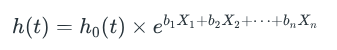
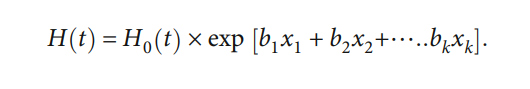

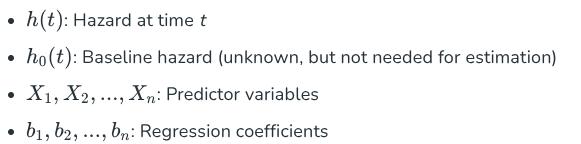

In [ ]:
import pandas as pd

from chagas_ml.analysis.cox_regressor import (
    normalize_columns,
    prepare_survival_dataframe,
    build_cox_dataframe,
    fit_cox_model,
    fit_lasso_cox,
    hr_table,
    split_hr_by_risk,
    non_zero_lasso_coefficients,
)


In [2]:
DATA_PATH = "/home/cristiancrr/Chagas---Machine-Learning/Chagas_DB_3.xlsx" 
              

if DATA_PATH.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

df.shape, df.head()

((815, 98),
    Id base  sexo Fecha de ingreso  Edad al ingreso  Tipo de Seguridad Social  \
 0        1     1       2025-06-09        72.862616                         0   
 1        2     1       2022-11-30        86.338259                         0   
 2        3     1       2022-08-08        83.325123                         0   
 3        4     1       2023-06-03        82.337165                         0   
 4        5     1       2024-01-24        70.618500                         0   
 
    escolaridad  Estado civil  area de residencia  Frecuencia cardiaca  \
 0            0             0                   1                   59   
 1            0             0                   1                   67   
 2            0             0                   1                   48   
 3            0             0                   1                  140   
 4            0             1                   1                   68   
 
    Presión diastólica cardíaca  ...  estancia hospita

In [ ]:
df = normalize_columns(df)
df.columns.tolist()[:50]


In [4]:
# --- survival columns ---
TIME_COL  = "tiempo sobrevida"         
EVENT_COL = "mortalidad seguimiento"   

predictors = [
    # sociodemográficas
    "Edad al ingreso", "sexo",

    # severidad / clínicas al ingreso
    "FEVI", "IMC", "Frecuencia cardiaca",
    "Presión sistólica cardíaca", "Presión diastólica cardíaca",

    # comorbilidades (ejemplos)
    "Hipertensión arterial", "Diabetes mellitus", "Dislipidemia",
    "Enfermedad coronaria", "Enfermedad renal crónica", "Arritmia",

    # Charlson
    "Charlson calculado",

    "IECA / ARA2 o ARNI", "Betabloqueadores", "Inhibidor de la aldosterona",
    "ISGLT2", "Anticoagulante", "Antiarrítmicos",

    # labs y biomarcadores
    "Pro-BNP", "Creatinina", "PCR", "BUN", "Potasio", "Glucosa",

    # hemograma
    "Leucocitos", "Hemoglobina", "Recuento de plaquetas", "RDW",
    "Neutrófilos", "Linfocitos", "Monocitos",

    # índices derivados 
    "NLR", "PLR", "SII", "SIRI", "AISI",
]

predictors = [c for c in predictors if c in df.columns]
missing = [c for c in set([
    "Edad al ingreso","sexo","FEVI","IMC","Frecuencia cardiaca",
    "Pro-BNP","Creatinina","PCR","BUN","Potasio","Glucosa"
]) if c not in df.columns]

print("N predictores usados:", len(predictors))
print("Ejemplo de faltantes (revisar nombres):", missing)

N predictores usados: 20
Ejemplo de faltantes (revisar nombres): []


In [ ]:
df_s = prepare_survival_dataframe(df, time_col=TIME_COL, event_col=EVENT_COL)
df_s[[TIME_COL, EVENT_COL]].head()


- numéricas -> float
- categóricas -> one-hot

In [ ]:
cox_df = build_cox_dataframe(
    df=df_s,
    predictors=predictors,
    time_col=TIME_COL,
    event_col=EVENT_COL,
    dropna=True,
)

cox_df.shape, cox_df.head()


Interpretación:
- HR > 1: aumenta la tasa instantánea de muerte (peor pronóstico)
- HR < 1: reduce la tasa instantánea de muerte (mejor pronóstico)

In [ ]:
cph = fit_cox_model(
    cox_df=cox_df,
    time_col=TIME_COL,
    event_col=EVENT_COL,
    penalizer=0.0,
    l1_ratio=0.0,
)
cph.print_summary()


In [ ]:
hr_table(cph).head(25)


In [ ]:
hr = hr_table(cph).copy()

predictores_mas_riesgosos, predictores_menos_riesgosos = split_hr_by_risk(hr)

print("Predictores mas riesgosos (HR > 1)")
display(predictores_mas_riesgosos)

print("Predictores menos riesgosos (HR < 1)")
display(predictores_menos_riesgosos)


# Lasso-Cox

The Lasso-Cox regression minimizes the penalized partial log-likelihood:



In [ ]:
lasso_cph = fit_lasso_cox(
    cox_df=cox_df,
    time_col=TIME_COL,
    event_col=EVENT_COL,
    penalizer=0.01,
)

print("Coeficientes no nulos (LASSO-Cox):")
display(non_zero_lasso_coefficients(lasso_cph)[["coef", "exp(coef)", "p"]])

print("HR table (LASSO-Cox):")
display(hr_table(lasso_cph).head(25))
